In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [ ]:
prices_raw_2 = pd.read_csv("prices_round_5_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_5_day_3.csv", sep = ";", index_col = "timestamp")
prices_raw_4 = pd.read_csv("prices_round_5_day_4.csv", sep = ";", index_col = "timestamp")
prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw_4.index = prices_raw_4.index + prices_raw_3.index.max() + 100
prices_raw = pd.concat([prices_raw_2, prices_raw_3, prices_raw_4], axis=0)
mid_prices = prices_raw[["product", "mid_price"]]
mid_prices = (
    mid_prices.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)

product,TRANSLATOR_ASTRO_BLACK,TRANSLATOR_ECLIPSE_CHARCOAL,TRANSLATOR_GRAPHITE_MIST,TRANSLATOR_SPACE_GRAY,TRANSLATOR_VOID_BLUE
timestamp,,,,,
0,10000.0,10000.0,10000.0,10000.0,10000.0
100,9986.5,10015.5,10006.5,10000.5,10002.5
200,9996.5,9996.5,10002.5,10002.5,10007.5
300,9974.5,9997.5,10010.5,9995.5,10009.5
400,9993.5,9993.5,10013.5,9988.5,10019.5
...,...,...,...,...,...
2999500,8978.0,9699.0,9786.5,8401.0,11532.5
2999600,8973.0,9698.5,9787.5,8409.5,11540.0
2999700,8961.0,9717.5,9800.5,8404.0,11548.0


In [ ]:
sector = mid_prices.filter(regex=r'^TRANSLATOR')
log_prices = np.log(sector.loc[2000000:])
a = log_prices.iloc[:, 0]
b = log_prices.iloc[:, 1]
c = log_prices.iloc[:, 2]
d = log_prices.iloc[:, 3]
e = log_prices.iloc[:, 4]
y5 = np.column_stack([a, b, c, d, e])

In [15]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(y5, 0, 1)
print("Trace Statistic: \n", result.lr1)
print("Trace Critical Values: \n", result.cvt)
print("Max Eigenvalue Statistic: \n", result.lr2)
print("Max Eigenvalue Critical Values: \n", result.cvm)

Trace Statistic: 
 [48.41893773 26.35022407 13.57139593  6.22740868  1.64499437]
Trace Critical Values: 
 [[65.8202 69.8189 77.8202]
 [44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max Eigenvalue Statistic: 
 [22.06871366 12.77882814  7.34398725  4.58241431  1.64499437]
Max Eigenvalue Critical Values: 
 [[31.2379 33.8777 39.3693]
 [25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [16]:
beta = result.evec[:, 0]
beta

array([ 15.77298288, -25.85430987,   2.96597223,  12.40700274,
        28.25881407])

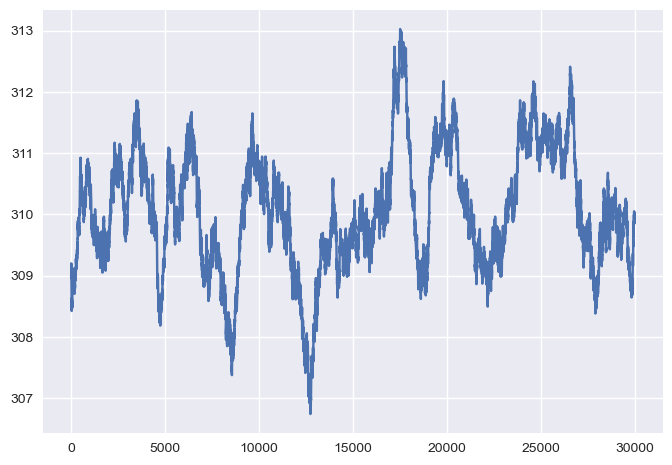

In [17]:
spread = y5 @ beta
plt.plot(spread)

In [13]:
import statsmodels.tsa.stattools as ts
cadf = ts.adfuller(spread)
print ('Augmented Dickey Fuller test statistic =',cadf[0])
print ('Augmented Dickey Fuller p-value =',cadf[1])
print ('Augmented Dickey Fuller 1%, 5% and 10% test statistics =',cadf[4])

Augmented Dickey Fuller test statistic = -3.499255114303039
Augmented Dickey Fuller p-value = 0.00800624492435872
Augmented Dickey Fuller 1%, 5% and 10% test statistics = {'1%': np.float64(-3.4305680025880942), '5%': np.float64(-2.8616363512511263), '10%': np.float64(-2.5668212848307097)}


In [9]:
spread.mean()

np.float64(331.526249336317)

In [10]:
spread.std()

np.float64(1.0034714623065943)